# 自定义messages及reducer
主要目标：
使用langgraph提供的reducer实现messages的自定义

## 新鲜的知识点
1. add_messages langgraph提供的消息reducer，用来管理消息列表
2. MessagesState类型，langgraph提供的消息类型，包含常用的消息类别

## 做些什么
做一个能够调用工具的简单agent，要求继承MessagesState实现扩展

步骤：
- 创建llm客户端
- 创建tool，并绑定到llm实例上
- 创建node，这个node就是把usermessage发送给模型得到计算答案
- 创建State
- 创建graph并编译和打印图结构
- 测试graph

In [56]:

# 通用步骤
from langchain_openai import ChatOpenAI


glm_client = ChatOpenAI(
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",
    model="glm-4.7",
)


In [57]:
# 创建tool
def multipy(a:int, b:int)->int:
    """计算 a 和 b 的乘积

    Args:
        a: 第一个数字
        b: 第二个数字
    """
    return a * b

glm_client_with_tool = glm_client.bind_tools([multipy])

In [ ]:
# 创建messagesstate
from typing import Annotated, TypedDict

from langchain.messages import AnyMessage
from langgraph.graph import add_messages


class MyMessagesState(TypedDict):
    msgs: Annotated[list[AnyMessage], add_messages]


In [59]:
# 创建节点
def multipy_node(state:MyMessagesState):
    return {"msgs":[glm_client_with_tool.invoke(state["msgs"])]}

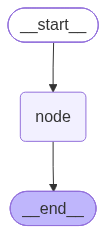

In [60]:
# 创建并打印graph
from langgraph.graph import END, START, StateGraph
from IPython.display import Image,display

graph = StateGraph(MyMessagesState)
graph.add_node("node",multipy_node)
graph.add_edge(START, "node")
graph.add_edge("node",END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [61]:
res = app.invoke({"msgs":[("user","2乘以3是多少")]})

In [62]:
for msg in res["msgs"]:
    msg.pretty_print()

================================ Human Message =================================

2乘以3是多少
================================== Ai Message ==================================
Tool Calls:
  multipy (call_-7347750816440118901)
 Call ID: call_-7347750816440118901
  Args:
    a: 2
    b: 3


In [71]:
res  = app.invoke({"msgs":[("user","hello")]})

In [73]:
for msg in res["msgs"]:
    msg.pretty_print()

================================ Human Message =================================

hello
================================== Ai Message ==================================

你好！很高兴见到你！有什么我可以帮助你的吗？
